# Train CARL Ratio Estimator: POI + Nuisance Parameters (No Interpolation)

Train a classifier to estimate $r(x|\theta,\nu) = p(x|\theta,\nu) / p(x|\theta_{\text{SM}}, \nu=0)$
where both the physics parameters $\theta = (C_W/\Lambda^2, C_{\tilde{W}}/\Lambda^2)$
and nuisance parameters $\nu = (\nu_{\mu_R}, \nu_{\mu_F})$ are inputs to the network.

**Key design choices**:

- The physical nuisance space is 2D: $(\nu_{\mu_R}, \nu_{\mu_F})$. The correlated
  scale variation (`scale_corr`) orresponds to the diagonal
  points $(\pm 1, \pm 1)$ in the 2D space.
- Nuisance parameters are restricted to the 7 actually-simulated points:
  the 4 axis points $(\pm 1, 0)$, $(0, \pm 1)$, the 2 diagonal points $(\pm 1, \pm 1)$,
  and nominal $(0, 0)$. No log-quadratic interpolation is used.
- Physics parameters use morphing (exact for EFT Wilson coefficients), so $\theta$
  is sampled continuously from a flat prior over the full parameter range.

The network receives 4 inputs: $[\theta_1, \theta_2, \nu_{\mu_R}, \nu_{\mu_F}]$.

**Input**: `data/lhe_data_semi_parametric_b1.h5`
**Output**: Trained model saved to `models/carl_nuisance`


## 0. Setup

In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from madminer.sampling import SampleAugmenter
from madminer.ml import ParameterizedRatioEstimator

logging.basicConfig(
    format="%(asctime)-5.5s %(name)-20.20s %(levelname)-7.7s %(message)s",
    datefmt="%H:%M",
    level=logging.INFO,
)
for key in logging.Logger.manager.loggerDict:
    if "madminer" not in key:
        logging.getLogger(key).setLevel(logging.WARNING)

## 1. Inspect Setup

In [2]:
sampler = SampleAugmenter("data/lhe_data_semi_parametric_b1.h5")

param_names = list(sampler.parameters.keys())
nuis_names = list(sampler.nuisance_parameters.keys())
n_params = len(param_names)
n_nuisance = len(nuis_names)

print(f"Physics params ({n_params}): {param_names}")
print(f"Nuisance params ({n_nuisance}): {nuis_names}")
print(f"Observables: {list(sampler.observables.keys())}")
print(f"Morphing: {sampler.morpher is not None}")
print(f"Nuisance morpher: {sampler.nuisance_morpher is not None}")

11:09 madminer.analysis.da INFO    Loading data from data/lhe_data_semi_parametric_b1.h5
11:09 madminer.utils.inter INFO    HDF5 file does not contain finite difference information
11:09 madminer.analysis.da INFO    Found 2 parameters
11:09 madminer.analysis.da INFO      0: CWL2 (LHA: dim6 2, Power: 2, Range: (np.float64(-20.0), np.float64(20.0)))
11:09 madminer.analysis.da INFO      1: CPWL2 (LHA: dim6 5, Power: 2, Range: (np.float64(-20.0), np.float64(20.0)))
11:09 madminer.analysis.da INFO    Found 3 nuisance parameters
11:09 madminer.analysis.da INFO      0: scale_mur_nuisance_param_0 (Systematic: scale_mur, Benchmarks: scale_mur_nuisance_param_0_benchmark_0 | scale_mur_nuisance_param_0_benchmark_1)
11:09 madminer.analysis.da INFO      1: scale_muf_nuisance_param_0 (Systematic: scale_muf, Benchmarks: scale_muf_nuisance_param_0_benchmark_0 | scale_muf_nuisance_param_0_benchmark_1)
11:09 madminer.analysis.da INFO      2: scale_corr_nuisance_param_0 (Systematic: scale_corr, Benchmarks

Physics params (2): ['CWL2', 'CPWL2']
Nuisance params (3): ['scale_mur_nuisance_param_0', 'scale_muf_nuisance_param_0', 'scale_corr_nuisance_param_0']
Observables: ['pt_j1', 'delta_phi_jj', 'met']
Morphing: True
Nuisance morpher: True


## 2. Extract Training Data at Simulated Nuisance Points

We use 7 points in the 2D $(\nu_{\mu_R}, \nu_{\mu_F})$ space that correspond
to actually-simulated MadGraph scale-variation weights:

| Point | $\nu_{\mu_R}$ | $\nu_{\mu_F}$ | MadGraph meaning |
|-------|---------------|---------------|------------------|
| Nominal | 0 | 0 | $\mu_R = 1\times$, $\mu_F = 1\times$ |
| $\mu_R$ up/down | ±1 | 0 | $\mu_R = 2\times / 0.5\times$ |
| $\mu_F$ up/down | 0 | ±1 | $\mu_F = 2\times / 0.5\times$ |
| Correlated up/down | ±1 | ±1 | Both scales varied together |

No interpolation or extrapolation is involved — each weight is computed
directly by MadGraph's systematics module.

For each nu configuration, we draw random $\theta$ values using morphing
(exact for EFT) and extract the CARL training tuples. Both numerator and
denominator events receive the same $[\theta, \nu]$ label, since it
represents the hypothesis being tested, not what generated the event.


In [3]:
output_dir = "data/samples_carl_nuis"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Physical nuisance space is 2D: (nu_muR, nu_muF)
# MadMiner internal space is 3D: [nu_mur, nu_muf, nu_corr]
# The corr benchmarks are diagonal points in the 2D space, not a 3rd axis.

n_nuis_phys = 2  # what the network sees

# 7 simulated points in 2D (nu_muR, nu_muF) and their 3D MadMiner mappings
nu_points = [
    # (nu_muR, nu_muF)   ->  MadMiner [nu_mur, nu_muf, nu_corr]
    (( 0.0,  0.0),          [0.0, 0.0, 0.0]),   # nominal
    (( 1.0,  0.0),          [1.0, 0.0, 0.0]),   # mur up
    ((-1.0,  0.0),          [-1.0, 0.0, 0.0]),  # mur down
    (( 0.0,  1.0),          [0.0, 1.0, 0.0]),   # muf up
    (( 0.0, -1.0),          [0.0, -1.0, 0.0]),  # muf down
    (( 1.0,  1.0),          [0.0, 0.0, 1.0]),   # corr up = diagonal in 2D
    ((-1.0, -1.0),          [0.0, 0.0, -1.0]),  # corr down = diagonal in 2D
]

print(f"Nuisance grid: {len(nu_points)} points in 2D (nu_muR, nu_muF) space")
for nu_2d, nu_3d in nu_points:
    print(f"  ({nu_2d[0]:+.0f}, {nu_2d[1]:+.0f})  ->  MadMiner {nu_3d}")

n_theta_per_nu = 50
samples_per_call = 20_000

rng = np.random.default_rng(42)
all_x, all_theta_ext, all_y, all_r_xz = [], [], [], []

for i_nu, (nu_2d, nu_3d) in enumerate(nu_points):
    is_nominal = np.allclose(nu_3d, 0.0)

    x, theta0, theta1, y, r_xz, t_xz, _ = sampler.sample_train_ratio(
        theta0=("random_morphing_points", (n_theta_per_nu, [
            ("flat", -20.0, 20.0),
            ("flat", -20.0, 20.0),
        ])),
        theta1=("benchmark", "sm"),
        nu0=None if is_nominal else ("morphing_point", np.array(nu_3d)),
        nu1=None,
        n_samples=samples_per_call,
        nuisance_score=False,
        test_split=0.001,
        validation_split=0.001,
        partition="train",
    )

    # MadMiner appends 3D nu to theta0 when nu0 is set — strip it and use 2D instead
    theta_phys = theta0[:, :n_params]  # first 2 columns always physics

    # # Build 2D nu column: nu_2d for numerator events (y=0), zero for denominator (y=1)
    # nu_col = np.zeros((len(x), n_nuis_phys))
    # num_mask = (y.flatten() == 0)
    # nu_col[num_mask] = nu_2d

    # ALL events get the same nu label — it's the hypothesis being tested
    # (denominator events are still generated at nu=0, but labeled with
    # the numerator's nu so the network learns the correct ratio)
    nu_col = np.full((len(x), n_nuis_phys), nu_2d)


    theta_ext = np.hstack([theta_phys, nu_col])  # shape (n, 4)

    all_x.append(x)
    all_theta_ext.append(theta_ext)
    all_y.append(y)
    all_r_xz.append(r_xz)

    print(f"  {i_nu + 1}/{len(nu_points)}: nu_2d=({nu_2d[0]:+.0f},{nu_2d[1]:+.0f}) done, {len(x)} samples")

# Concatenate and shuffle
X = np.vstack(all_x)
Theta = np.vstack(all_theta_ext)
Y = np.vstack(all_y)
R = np.vstack(all_r_xz)

perm = rng.permutation(len(X))
X, Theta, Y, R = X[perm], Theta[perm], Y[perm], R[perm]

# Train/test split
n_test = int(0.2 * len(X))
np.save(f"{output_dir}/x_train.npy", X[n_test:])
np.save(f"{output_dir}/theta_ext_train.npy", Theta[n_test:])
np.save(f"{output_dir}/y_train.npy", Y[n_test:])
np.save(f"{output_dir}/r_xz_train.npy", R[n_test:])
np.save(f"{output_dir}/x_test.npy", X[:n_test])
np.save(f"{output_dir}/theta_ext_test.npy", Theta[:n_test])
np.save(f"{output_dir}/y_test.npy", Y[:n_test])
np.save(f"{output_dir}/r_xz_test.npy", R[:n_test])

print(f"\nTotal samples: {len(X)}")
print(f"  Train: {len(X) - n_test}")
print(f"  Test:  {n_test}")
print(f"  Extended theta shape: {Theta.shape[1]} = {n_params} POI + {n_nuis_phys} NP")
print(f"  NP grid: 7 simulated points in (nu_muR, nu_muF) — no interpolation")

del all_x, all_theta_ext, all_y, all_r_xz, X, Theta, Y, R, x, theta0, theta1, y, r_xz, t_xz
del sampler
import gc; gc.collect()


11:09 madminer.sampling.sa INFO    Extracting training sample for ratio-based methods. Numerator hypothesis: 50 random morphing points, drawn from the following priors: 
  theta_0 ~ flat from -20.0 to 20.0
  theta_1 ~ flat from -20.0 to 20.0, denominator hypothesis: sm
11:09 madminer.sampling.sa INFO    Starting sampling serially
11:09 madminer.sampling.sa INFO    Sampling from parameter point 2 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 4 / 50


Nuisance grid: 7 points in 2D (nu_muR, nu_muF) space
  (+0, +0)  ->  MadMiner [0.0, 0.0, 0.0]
  (+1, +0)  ->  MadMiner [1.0, 0.0, 0.0]
  (-1, +0)  ->  MadMiner [-1.0, 0.0, 0.0]
  (+0, +1)  ->  MadMiner [0.0, 1.0, 0.0]
  (+0, -1)  ->  MadMiner [0.0, -1.0, 0.0]
  (+1, +1)  ->  MadMiner [0.0, 0.0, 1.0]
  (-1, -1)  ->  MadMiner [0.0, 0.0, -1.0]


11:09 madminer.sampling.sa INFO    Sampling from parameter point 6 / 50
11:09 madminer.sampling.sa WARNING Large statistical uncertainty on the total cross section when sampling from theta = [-2.1707408 -5.2410693]: (0.010114 +/- 0.001135) pb (11.222974740088112 %). Skipping these warnings in the future...
11:09 madminer.sampling.sa INFO    Sampling from parameter point 8 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 10 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 12 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 14 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 16 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 18 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 20 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 22 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 24 / 50
11:09 madminer.sampling.sa INFO    S

  1/7: nu_2d=(+0,+0) done, 20000 samples


11:09 madminer.sampling.sa INFO    Sampling from parameter point 4 / 50
11:09 madminer.sampling.sa WARNING Large statistical uncertainty on the total cross section when sampling from theta = [-0.69597876 -6.2838283 ]: (0.011671 +/- 0.001645) pb (14.094405330305214 %). Skipping these warnings in the future...
11:09 madminer.sampling.sa INFO    Sampling from parameter point 6 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 8 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 10 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 12 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 14 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 16 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 18 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 20 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 22 / 50
11:09 madminer.sampling.sa INFO    

...

11:09 madminer.sampling.sa INFO    Sampling from parameter point 4 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 6 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 8 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 10 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 12 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 14 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 16 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 18 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 20 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 22 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 24 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 26 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 28 / 50
11:09 madminer.sampling.sa INFO    Sampling from param

  6/7: nu_2d=(+1,+1) done, 20000 samples


11:09 madminer.sampling.sa INFO    Sampling from parameter point 4 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 6 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 8 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 10 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 12 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 14 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 16 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 18 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 20 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 22 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 24 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 26 / 50
11:09 madminer.sampling.sa INFO    Sampling from parameter point 28 / 50
11:09 madminer.sampling.sa INFO    Sampling from param

  7/7: nu_2d=(-1,-1) done, 20000 samples

Total samples: 140000
  Train: 112000
  Test:  28000
  Extended theta shape: 4 = 2 POI + 2 NP
  NP grid: 7 simulated points in (nu_muR, nu_muF) — no interpolation


0

## 3. Train CARL with Extended Parameters

The `ParameterizedRatioEstimator` treats whatever is passed as `theta` as the
parameter input to the network. By passing $[\theta_{\text{phys}}, \nu]$, the
network learns $\hat{r}(x | \theta, \nu)$ directly.

In [4]:
estimator = ParameterizedRatioEstimator(
    n_hidden=(256, 256, 256),
    activation="tanh",
)

losses_train, losses_val = estimator.train(
    method="carl",
    x=f"{output_dir}/x_train.npy",
    y=f"{output_dir}/y_train.npy",
    theta=f"{output_dir}/theta_ext_train.npy",
    n_epochs=50,
    batch_size=256,
    initial_lr=1e-3,
    final_lr=1e-5,
    validation_split=0.25,
    early_stopping=True,
    early_stopping_patience=10,
)

estimator.save("models/carl_nuisance")
print("Model saved to models/carl_nuisance")

11:09 madminer.ml.paramete INFO    Starting training
11:09 madminer.ml.paramete INFO      Method:                 carl
11:09 madminer.ml.paramete INFO      Batch size:             256
11:09 madminer.ml.paramete INFO      Optimizer:              amsgrad
11:09 madminer.ml.paramete INFO      Epochs:                 50
11:09 madminer.ml.paramete INFO      Learning rate:          0.001 initially, decaying to 1e-05
11:09 madminer.ml.paramete INFO      Validation split:       0.25
11:09 madminer.ml.paramete INFO      Early stopping:         True
11:09 madminer.ml.paramete INFO      Scale inputs:           True
11:09 madminer.ml.paramete INFO      Scale parameters:       True
11:09 madminer.ml.paramete INFO      Shuffle labels          False
11:09 madminer.ml.paramete INFO      Samples:                all
11:09 madminer.ml.paramete INFO    Loading training data
11:09 madminer.utils.vario INFO      Loading data/samples_carl_nuis/theta_ext_train.npy into RAM
11:09 madminer.utils.vario INFO      

Model saved to models/carl_nuisance


## 4. Training Loss

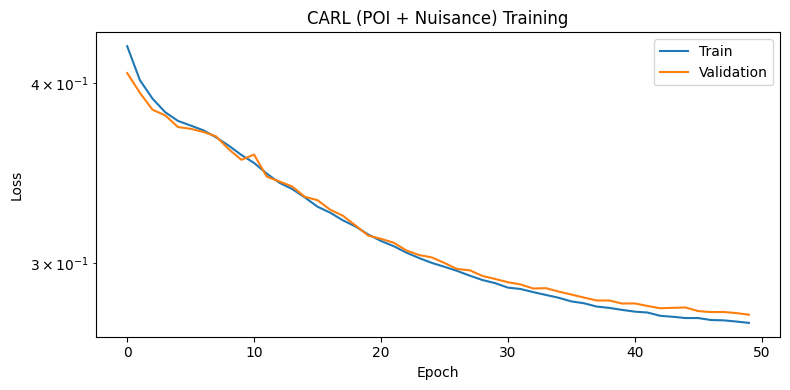

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_train, label="Train")
ax.plot(losses_val, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CARL (POI + Nuisance) Training")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 5. Evaluate: Predicted vs True

In [6]:
model = ParameterizedRatioEstimator()
model.load("models/carl_nuisance")

x_test_arr = np.load(f"{output_dir}/x_test.npy")
theta_test_arr = np.load(f"{output_dir}/theta_ext_test.npy")
r_xz_test = np.load(f"{output_dir}/r_xz_test.npy")

batch_size = 10_000
log_r_parts = []
for start in range(0, len(x_test_arr), batch_size):
    end = min(start + batch_size, len(x_test_arr))
    lr, _ = model.evaluate_log_likelihood_ratio(
        x=x_test_arr[start:end],
        theta=theta_test_arr[start:end],
        test_all_combinations=False,
    )
    log_r_parts.append(lr)
log_r_hat = np.concatenate(log_r_parts)
log_r_true = np.log(r_xz_test.flatten())

print(f"Predicted: shape={log_r_hat.shape}, mean={log_r_hat.mean():.3f}")
print(f"True:      shape={log_r_true.shape}, mean={log_r_true.mean():.3f}")

11:11 madminer.ml.base     INFO    Loading model from models/carl_nuisance


Predicted: shape=(28000,), mean=0.318
True:      shape=(28000,), mean=0.279


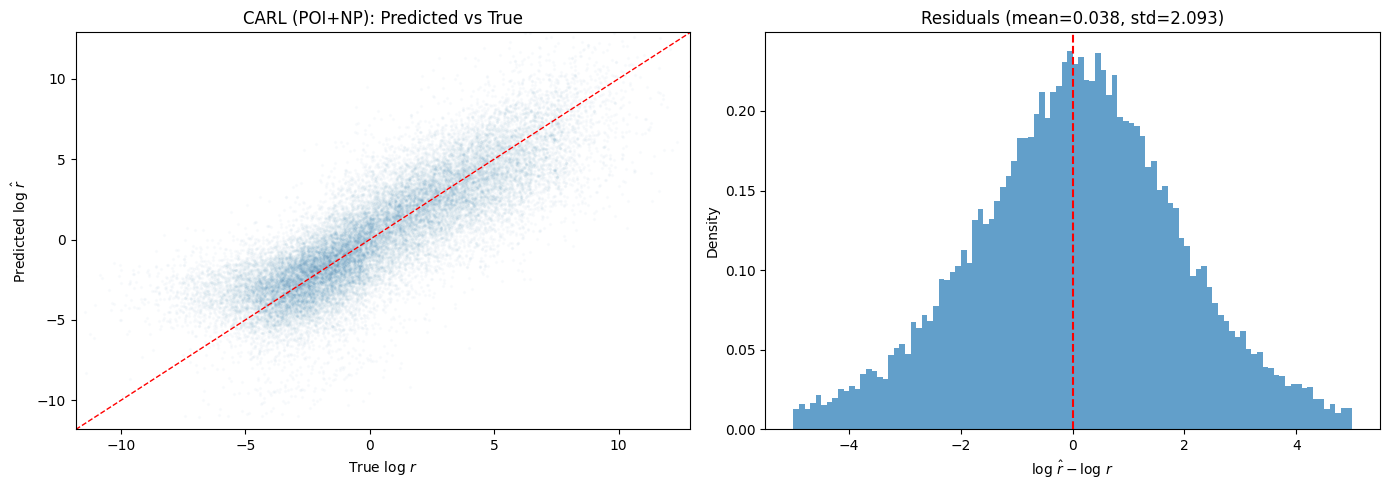

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
finite = np.isfinite(log_r_true) & np.isfinite(log_r_hat)
ax.scatter(log_r_true[finite], log_r_hat[finite], alpha=0.02, s=2, rasterized=True)
lims = [max(log_r_true[finite].min(), -20), min(log_r_true[finite].max(), 20)]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel(r"True $\log\, r$")
ax.set_ylabel(r"Predicted $\log\, \hat{r}$")
ax.set_title("CARL (POI+NP): Predicted vs True")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax = axes[1]
residuals = log_r_hat[finite] - log_r_true[finite]
ax.hist(residuals, bins=100, range=(-5, 5), density=True, alpha=0.7)
ax.axvline(0, color="r", ls="--")
ax.set_xlabel(r"$\log\,\hat{r} - \log\,r$")
ax.set_ylabel("Density")
ax.set_title(f"Residuals (mean={residuals.mean():.3f}, std={residuals.std():.3f})")

plt.tight_layout()
plt.show()

## 6. Nuisance Parameter Impact

Compare the log likelihood ratio at a fixed $\theta$ as a function of $\nu$
to verify the network has learned the nuisance dependence.

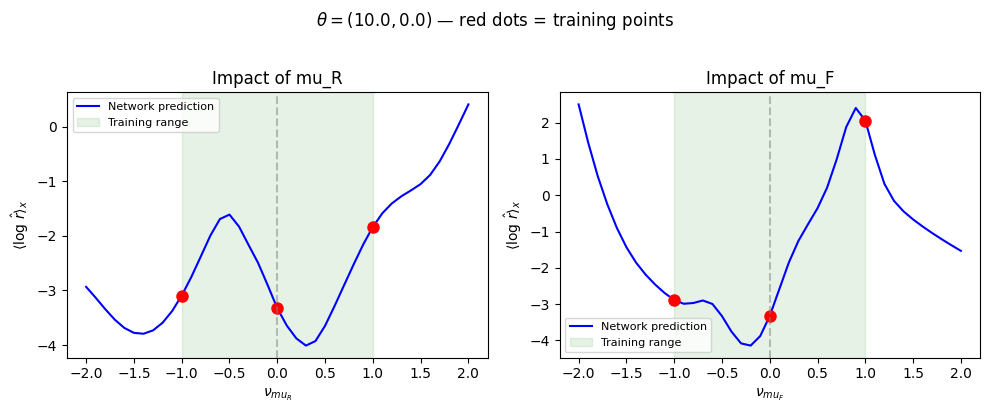

In [8]:
# Pick a non-SM theta to see the effect
theta_fixed = np.array([10.0, 0.0, 0.0, 0.0])  # CWL2, CPWL2, nu_muR, nu_muF
nuis_labels = ["mu_R", "mu_F"]
nu_scan = np.linspace(-2, 2, 41)


# Scan nu continuously to see how the network interpolates between the
# 3 training points (nu = -1, 0, +1)
x_sm = np.load(f"{output_dir}/x_test.npy")
y_test = np.load(f"{output_dir}/y_test.npy")
sm_mask = (y_test.flatten() == 1)
x_sm = x_sm[sm_mask][:500]
del y_test


fig, axes = plt.subplots(1, n_nuis_phys, figsize=(5 * n_nuis_phys, 4))
if n_nuis_phys == 1:
    axes = [axes]

for i_nuis in range(n_nuis_phys):
    mean_log_r = []
    for nu_val in nu_scan:
        nu_vec = np.zeros(n_nuis_phys)
        nu_vec[i_nuis] = nu_val
        theta_ext = theta_fixed.copy()
        theta_ext[n_params:] = nu_vec
        theta_batch = np.tile(theta_ext, (len(x_sm), 1))

        lr, _ = model.evaluate_log_likelihood_ratio(
            x=x_sm, theta=theta_batch, test_all_combinations=False,
        )
        mean_log_r.append(lr.mean())

    ax = axes[i_nuis]
    ax.plot(nu_scan, mean_log_r, "b-", label="Network prediction")
    # Mark the training points
    for nv in [-1, 0, 1]:
        idx = np.argmin(np.abs(nu_scan - nv))
        ax.plot(nv, mean_log_r[idx], "ro", markersize=8)
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.axvspan(-1, 1, alpha=0.1, color="green", label="Training range")
    ax.set_xlabel(rf"$\nu_{{{nuis_labels[i_nuis]}}}$")
    ax.set_ylabel(r"$\langle \log\, \hat{r} \rangle_x$")
    ax.set_title(f"Impact of {nuis_labels[i_nuis]}")
    ax.legend(fontsize=8)

plt.suptitle(rf"$\theta = ({theta_fixed[0]}, {theta_fixed[1]})$ — red dots = training points", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Check training data sanity
theta_ext = np.load(f"{output_dir}/theta_ext_train.npy")
r_xz = np.load(f"{output_dir}/r_xz_train.npy").flatten()
y = np.load(f"{output_dir}/y_train.npy").flatten()

print(f"theta_ext shape: {theta_ext.shape}")
print(f"theta_ext columns: [CWL2, CPWL2, nu_muR, nu_muF]")
print()

# Check unique nu values in training data
nu_cols = theta_ext[:, n_params:]
unique_nu = np.unique(nu_cols, axis=0)
print(f"Unique nu configurations: {len(unique_nu)}")
for nu in unique_nu:
    mask = np.all(nu_cols == nu, axis=1)
    r_vals = r_xz[mask]
    y_vals = y[mask]
    print(f"  nu=({nu[0]:+.0f},{nu[1]:+.0f}): {mask.sum():6d} samples, "
          f"y=0: {(y_vals==0).sum()}, y=1: {(y_vals==1).sum()}, "
          f"mean log r = {np.log(r_vals[r_vals>0]).mean():.3f}, "
          f"median log r = {np.median(np.log(r_vals[r_vals>0])):.3f}")

del theta_ext, r_xz, y


theta_ext shape: (112000, 4)
theta_ext columns: [CWL2, CPWL2, nu_muR, nu_muF]

Unique nu configurations: 7
  nu=(-1,-1):  15958 samples, y=0: 7979, y=1: 7979, mean log r = 0.313, median log r = -0.224
  nu=(-1,+0):  15973 samples, y=0: 7983, y=1: 7990, mean log r = 0.271, median log r = -0.222
  nu=(+0,-1):  16050 samples, y=0: 8102, y=1: 7948, mean log r = 0.336, median log r = -0.156
  nu=(+0,+0):  15994 samples, y=0: 7975, y=1: 8019, mean log r = 0.270, median log r = -0.239
  nu=(+0,+1):  15949 samples, y=0: 8000, y=1: 7949, mean log r = 0.297, median log r = -0.155
  nu=(+1,+0):  16062 samples, y=0: 8040, y=1: 8022, mean log r = 0.309, median log r = -0.124
  nu=(+1,+1):  16014 samples, y=0: 8011, y=1: 8003, mean log r = 0.315, median log r = -0.158


  Row 5/25
  Row 10/25
  Row 15/25
  Row 20/25
  Row 25/25


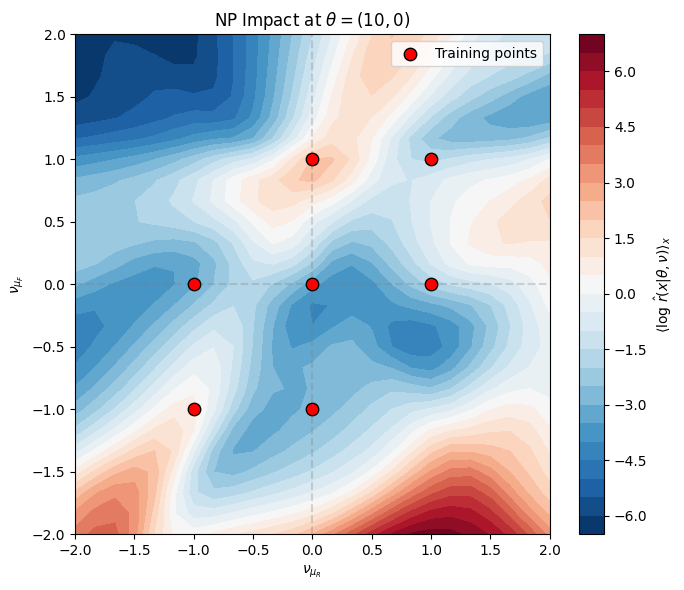

In [10]:
# Pick a non-SM theta to see the effect
theta_fixed = np.array([10.0, 0.0, 0.0, 0.0])  # CWL2, CPWL2, nu_muR, nu_muF

# Load SM-distributed test events
x_sm = np.load(f"{output_dir}/x_test.npy")
y_test = np.load(f"{output_dir}/y_test.npy")
sm_mask = (y_test.flatten() == 1)
x_sm = x_sm[sm_mask][:500]
del y_test

# 2D scan over (nu_muR, nu_muF)
n_nu_grid = 25
nu_vals = np.linspace(-2, 2, n_nu_grid)
nu_mur_grid, nu_muf_grid = np.meshgrid(nu_vals, nu_vals)

mean_log_r_2d = np.zeros((n_nu_grid, n_nu_grid))

for i in range(n_nu_grid):
    for j in range(n_nu_grid):
        theta_ext = theta_fixed.copy()
        theta_ext[n_params:] = [nu_mur_grid[i, j], nu_muf_grid[i, j]]
        theta_batch = np.tile(theta_ext, (len(x_sm), 1))

        lr, _ = model.evaluate_log_likelihood_ratio(
            x=x_sm, theta=theta_batch, test_all_combinations=False,
        )
        mean_log_r_2d[i, j] = lr.mean()
    if (i + 1) % 5 == 0:
        print(f"  Row {i+1}/{n_nu_grid}")

# The 7 training points in 2D
train_pts = np.array([
    [0, 0], [1, 0], [-1, 0], [0, 1], [0, -1], [1, 1], [-1, -1],
], dtype=float)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(nu_mur_grid, nu_muf_grid, mean_log_r_2d, levels=30, cmap="RdBu_r")
plt.colorbar(c, ax=ax, label=r"$\langle \log\, \hat{r}(x|\theta,\nu) \rangle_x$")
ax.scatter(train_pts[:, 0], train_pts[:, 1], c="red", s=80, zorder=5,
           edgecolors="black", label="Training points")
ax.set_xlabel(r"$\nu_{\mu_R}$")
ax.set_ylabel(r"$\nu_{\mu_F}$")
ax.set_title(rf"NP Impact at $\theta = ({theta_fixed[0]:.0f}, {theta_fixed[1]:.0f})$")
ax.axhline(0, color="gray", ls="--", alpha=0.3)
ax.axvline(0, color="gray", ls="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Profiled NLL Scan

For each $\theta$ grid point, minimize $-2 \sum_i \log \hat{r}(x_i|\theta,\nu)$
over $\nu$ (profiling). Compare with the fixed $\nu=0$ result.

In [11]:
from scipy.optimize import minimize

x_sm_prof = x_sm[:1000]

n_grid = 15
cwl2_vals = np.linspace(-15, 15, n_grid)
cpwl2_vals = np.linspace(-15, 15, n_grid)
cwl2_grid, cpwl2_grid = np.meshgrid(cwl2_vals, cpwl2_vals)

nll_fixed = np.zeros((n_grid, n_grid))
nll_profiled = np.zeros((n_grid, n_grid))
best_nu = np.zeros((n_grid, n_grid, n_nuis_phys))

def neg_log_lr(nu_vec, theta_phys, x_events):
    theta_ext = theta_phys.copy()
    theta_ext[n_params:] = nu_vec

    theta_batch = np.tile(theta_ext, (len(x_events), 1))
    lr, _ = model.evaluate_log_likelihood_ratio(
        x=x_events, theta=theta_batch, test_all_combinations=False,
    )
    return -2.0 * lr.sum()

for i in range(n_grid):
    for j in range(n_grid):
        theta_phys = np.array([cwl2_vals[j], cpwl2_vals[i], 0.0, 0.0])

        # Fixed nu=0
        nll_fixed[i, j] = neg_log_lr(np.zeros(n_nuis_phys), theta_phys, x_sm_prof)

        # Profile over nu — restrict to [-1, 1] (training range)
        res = minimize(
            neg_log_lr, x0=np.zeros(n_nuis_phys),
            args=(theta_phys, x_sm_prof),
            method="L-BFGS-B",
            bounds=[(-1, 1)] * n_nuis_phys,
        )
        nll_profiled[i, j] = res.fun
        best_nu[i, j] = res.x

    print(f"  Row {i+1}/{n_grid} done")

nll_fixed -= nll_fixed.min()
nll_profiled -= nll_profiled.min()

  Row 1/15 done
  Row 2/15 done
  Row 3/15 done
  Row 4/15 done
  Row 5/15 done
  Row 6/15 done
  Row 7/15 done
  Row 8/15 done
  Row 9/15 done
  Row 10/15 done
  Row 11/15 done
  Row 12/15 done
  Row 13/15 done
  Row 14/15 done
  Row 15/15 done


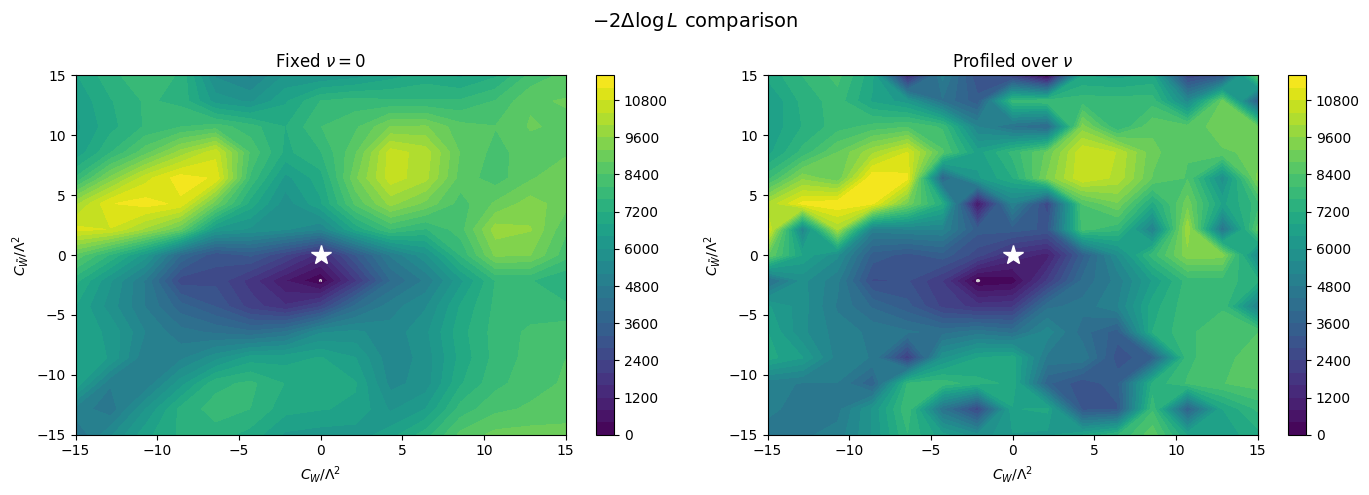

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nll_data, title in [
    (axes[0], nll_fixed, r"Fixed $\nu = 0$"),
    (axes[1], nll_profiled, r"Profiled over $\nu$"),
]:
    c = ax.contourf(cwl2_grid, cpwl2_grid, nll_data, levels=30, cmap="viridis")
    plt.colorbar(c, ax=ax)
    ax.contour(cwl2_grid, cpwl2_grid, nll_data, levels=[2.30, 5.99],
               colors=["white", "lightgray"], linewidths=2)
    ax.plot(0, 0, "w*", markersize=15)
    ax.set_xlabel(r"$C_{W}/\Lambda^2$")
    ax.set_ylabel(r"$C_{\tilde{W}}/\Lambda^2$")
    ax.set_title(title)

plt.suptitle(r"$-2\Delta\log L$ comparison", fontsize=14)
plt.tight_layout()
plt.show()

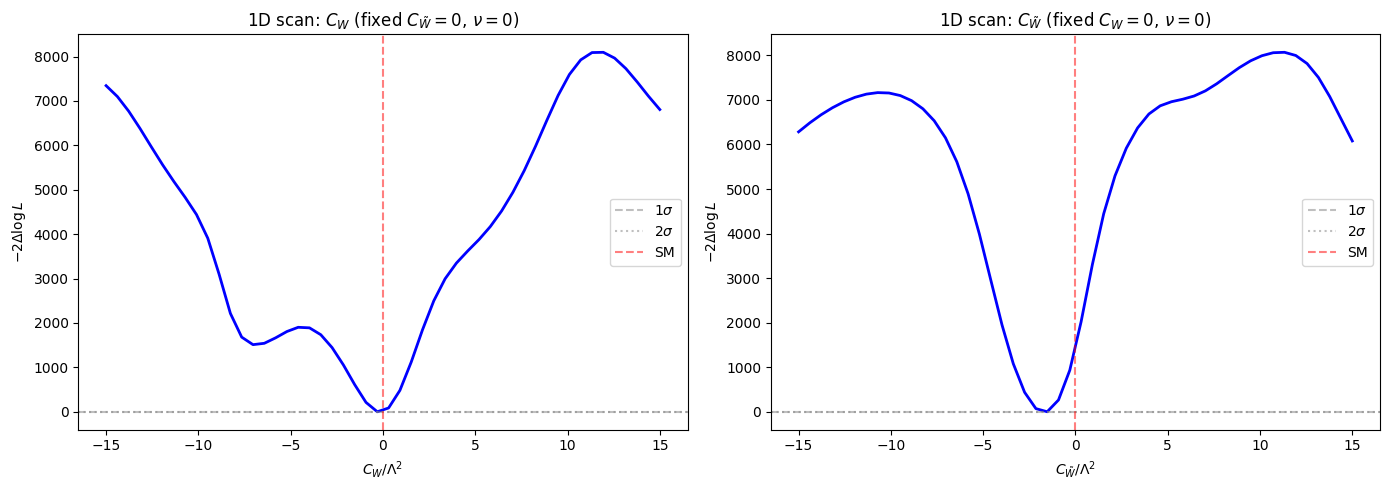

In [13]:
# 1D NLL scans at fixed nu=0

x_sm_1d = x_sm[:1000]

n_scan = 50
cwl2_scan = np.linspace(-15, 15, n_scan)
cpwl2_scan = np.linspace(-15, 15, n_scan)

def nll_1d(param_vals, param_idx, other_val=0.0):
    """Scan one POI, fix the other at other_val, nu=0."""
    nll_vals = []
    for v in param_vals:
        theta = np.array([0.0, 0.0, 0.0, 0.0])
        theta[param_idx] = v
        theta[1 - param_idx] = other_val
        theta_batch = np.tile(theta, (len(x_sm_1d), 1))
        lr, _ = model.evaluate_log_likelihood_ratio(
            x=x_sm_1d, theta=theta_batch, test_all_combinations=False,
        )
        nll_vals.append(-2.0 * lr.sum())
    return np.array(nll_vals)

nll_cwl2 = nll_1d(cwl2_scan, 0)
nll_cpwl2 = nll_1d(cpwl2_scan, 1)
nll_cwl2 -= nll_cwl2.min()
nll_cpwl2 -= nll_cpwl2.min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cwl2_scan, nll_cwl2, "b-", lw=2)
ax.axhline(1.0, color="gray", ls="--", alpha=0.5, label=r"$1\sigma$")
ax.axhline(4.0, color="gray", ls=":", alpha=0.5, label=r"$2\sigma$")
ax.axvline(0, color="red", ls="--", alpha=0.5, label="SM")
ax.set_xlabel(r"$C_W / \Lambda^2$")
ax.set_ylabel(r"$-2\Delta\log L$")
ax.set_title(r"1D scan: $C_W$ (fixed $C_{\tilde{W}}=0$, $\nu=0$)")
ax.legend()

ax = axes[1]
ax.plot(cpwl2_scan, nll_cpwl2, "b-", lw=2)
ax.axhline(1.0, color="gray", ls="--", alpha=0.5, label=r"$1\sigma$")
ax.axhline(4.0, color="gray", ls=":", alpha=0.5, label=r"$2\sigma$")
ax.axvline(0, color="red", ls="--", alpha=0.5, label="SM")
ax.set_xlabel(r"$C_{\tilde{W}} / \Lambda^2$")
ax.set_ylabel(r"$-2\Delta\log L$")
ax.set_title(r"1D scan: $C_{\tilde{W}}$ (fixed $C_W=0$, $\nu=0$)")
ax.legend()

plt.tight_layout()
plt.show()


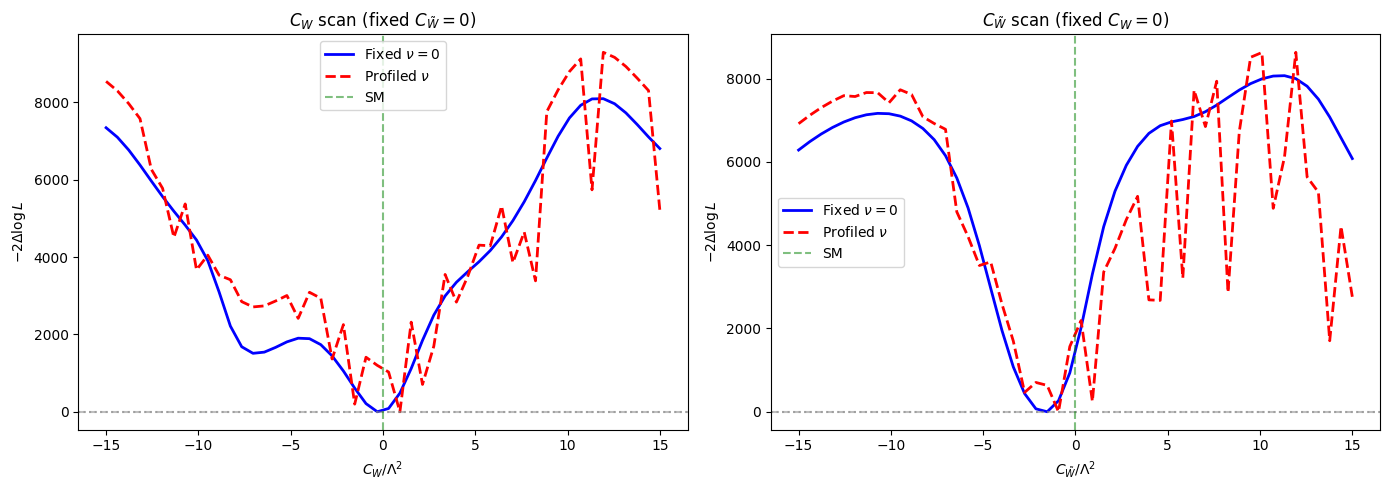

In [14]:
# 1D NLL scans — profiled over nu vs fixed nu=0

from scipy.optimize import minimize

def nll_1d_profiled(param_vals, param_idx, other_val=0.0):
    """Scan one POI, fix the other, profile over nu."""
    nll_fixed_list = []
    nll_prof_list = []
    for v in param_vals:
        theta_base = np.array([0.0, 0.0, 0.0, 0.0])
        theta_base[param_idx] = v
        theta_base[1 - param_idx] = other_val

        # Fixed nu=0
        theta_batch = np.tile(theta_base, (len(x_sm_1d), 1))
        lr, _ = model.evaluate_log_likelihood_ratio(
            x=x_sm_1d, theta=theta_batch, test_all_combinations=False,
        )
        nll_fixed_list.append(-2.0 * lr.sum())

        # Profile over nu
        def neg_llr(nu_vec):
            theta_prof = theta_base.copy()
            theta_prof[n_params:] = nu_vec
            theta_batch = np.tile(theta_prof, (len(x_sm_1d), 1))
            lr, _ = model.evaluate_log_likelihood_ratio(
                x=x_sm_1d, theta=theta_batch, test_all_combinations=False,
            )
            return -2.0 * lr.sum()

        res = minimize(neg_llr, x0=np.zeros(n_nuis_phys),
                       method="L-BFGS-B", bounds=[(-1, 1)] * n_nuis_phys)
        nll_prof_list.append(res.fun)

    return np.array(nll_fixed_list), np.array(nll_prof_list)

nll_cwl2_fix, nll_cwl2_prof = nll_1d_profiled(cwl2_scan, 0)
nll_cpwl2_fix, nll_cpwl2_prof = nll_1d_profiled(cpwl2_scan, 1)

# Shift so minimum is 0
nll_cwl2_fix -= nll_cwl2_fix.min()
nll_cwl2_prof -= nll_cwl2_prof.min()
nll_cpwl2_fix -= nll_cpwl2_fix.min()
nll_cpwl2_prof -= nll_cpwl2_prof.min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cwl2_scan, nll_cwl2_fix, "b-", lw=2, label=r"Fixed $\nu=0$")
ax.plot(cwl2_scan, nll_cwl2_prof, "r--", lw=2, label=r"Profiled $\nu$")
ax.axhline(1.0, color="gray", ls="--", alpha=0.5)
ax.axhline(4.0, color="gray", ls=":", alpha=0.5)
ax.axvline(0, color="green", ls="--", alpha=0.5, label="SM")
ax.set_xlabel(r"$C_W / \Lambda^2$")
ax.set_ylabel(r"$-2\Delta\log L$")
ax.set_title(r"$C_W$ scan (fixed $C_{\tilde{W}}=0$)")
ax.legend()

ax = axes[1]
ax.plot(cpwl2_scan, nll_cpwl2_fix, "b-", lw=2, label=r"Fixed $\nu=0$")
ax.plot(cpwl2_scan, nll_cpwl2_prof, "r--", lw=2, label=r"Profiled $\nu$")
ax.axhline(1.0, color="gray", ls="--", alpha=0.5)
ax.axhline(4.0, color="gray", ls=":", alpha=0.5)
ax.axvline(0, color="green", ls="--", alpha=0.5, label="SM")
ax.set_xlabel(r"$C_{\tilde{W}} / \Lambda^2$")
ax.set_ylabel(r"$-2\Delta\log L$")
ax.set_title(r"$C_{\tilde{W}}$ scan (fixed $C_W=0$)")
ax.legend()

plt.tight_layout()
plt.show()
